In [1]:
#Setup
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

base = '/content/drive/MyDrive/PTSD_Project'
processed = base + '/data/processed'
results = base + '/results'

print("done")

Mounted at /content/drive
done


In [2]:
# Load all saved results
with open(results + '/all_predictions.pkl', 'rb') as f:
    all_preds = pickle.load(f)

pred_f1_zero = all_preds['pred_f1_zero']
pred_f1_few  = all_preds['pred_f1_few']
pred_f2_zero = all_preds['pred_f2_zero']
pred_f2_few  = all_preds['pred_f2_few']
pred_f3_zero = all_preds['pred_f3_zero']
pred_f3_few  = all_preds['pred_f3_few']
pred_f4_zero = all_preds['pred_f4_zero']
pred_f4_few  = all_preds['pred_f4_few']
y_sample     = pd.Series(all_preds['y_sample'])
sample_idx   = all_preds['sample_idx']

# load original test rows for patient details
from sklearn.model_selection import train_test_split
merged = pd.read_csv(processed + '/merged_clean.csv')
y = merged['label']
_, X_test_orig, _, _ = train_test_split(
    merged, y, test_size=0.2, random_state=42, stratify=y
)
X_test_orig = X_test_orig.reset_index(drop=True)
X_sample = X_test_orig.iloc[sample_idx].reset_index(drop=True)

# load baseline ml metrics
baseline_metrics = pd.read_csv(results + '/baseline_metrics.csv')
llm_metrics = pd.read_csv(results + '/llm_metrics.csv')

print("loaded!")
print("sample size:", len(y_sample))
print("\nbaseline metrics:")
print(baseline_metrics)

loaded!
sample size: 200

baseline metrics:
                 Model  Accuracy  F1_macro   ROC_AUC
0  Logistic Regression  0.989141  0.968791  1.000000
1        Random Forest  0.974334  0.911783  0.994884
2              XGBoost  0.979269  0.940419  0.997628


In [4]:
# Full comparison table ML vs LLM
ml_rows = [
    {'Model': 'Logistic Regression', 'F1_macro': 0.9688, 'Accuracy': 0.9891, 'Note': 'full test set (1013)'},
    {'Model': 'Random Forest',       'F1_macro': 0.9118, 'Accuracy': 0.9743, 'Note': 'full test set (1013)'},
    {'Model': 'XGBoost',             'F1_macro': 0.9404, 'Accuracy': 0.9793, 'Note': 'full test set (1013)'},
]

llm_rows = []
for _, row in llm_metrics.iterrows():
    llm_rows.append({
        'Model': f"LLM ({row['Experiment']})",
        'F1_macro': row['F1_macro'],
        'Accuracy': row['Accuracy'],
        'Note': f"sample of {row['Valid']}/200"
    })

comparison = pd.DataFrame(ml_rows + llm_rows)
comparison = comparison.sort_values('F1_macro', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))
comparison.to_csv(results + '/full_comparison.csv', index=False)
print("\nsaved")

              Model  F1_macro  Accuracy                 Note
       LLM (F3_few)    1.0000    1.0000     sample of 24/200
Logistic Regression    0.9688    0.9891 full test set (1013)
            XGBoost    0.9404    0.9793 full test set (1013)
      Random Forest    0.9118    0.9743 full test set (1013)
      LLM (F1_zero)    0.8404    0.9400    sample of 200/200
      LLM (F2_zero)    0.8306    0.9350    sample of 200/200
       LLM (F1_few)    0.8306    0.9350    sample of 200/200
      LLM (F4_zero)    0.8075    0.9104     sample of 67/200
       LLM (F2_few)    0.7545    0.8519     sample of 27/200
       LLM (F4_few)    0.7222    0.9000     sample of 20/200
      LLM (F3_zero)    0.7188    0.8317    sample of 101/200

saved


In [6]:
# Find failure cases
# using F1_zero as the main LLM experiment (most reliable - 200/200 valid)

# calculate PHQ total for each patient in sample
phq_cols = ['DPQ010','DPQ020','DPQ030','DPQ040','DPQ050',
            'DPQ060','DPQ070','DPQ080','DPQ090']

X_sample['PHQ_total'] = X_sample[phq_cols].sum(axis=1)

# build analysis dataframe
analysis_df = X_sample.copy()
analysis_df['y_true'] = y_sample.values
analysis_df['pred_f1_zero'] = pred_f1_zero
analysis_df['pred_f1_few'] = pred_f1_few
analysis_df['pred_f2_zero'] = pred_f2_zero

# failure cases: LLM wrong (F1_zero), true label is available
# type 1: false positive - LLM said 1 but actual is 0
fp_cases = analysis_df[(analysis_df['pred_f1_zero'] == 1) &
                        (analysis_df['y_true'] == 0)]

# type 2: false negative - LLM said 0 but actual is 1
fn_cases = analysis_df[(analysis_df['pred_f1_zero'] == -1) |
                        ((analysis_df['pred_f1_zero'] == 0) &
                         (analysis_df['y_true'] == 1))]

print("False Positives (LLM said high risk, actually low risk):", len(fp_cases))
print("False Negatives (LLM missed high risk):", len(fn_cases))

fp_cases.to_csv(results + '/failure_cases_fp.csv', index=False)
fn_cases.to_csv(results + '/failure_cases_fn.csv', index=False)
print("\nsaved")

False Positives (LLM said high risk, actually low risk): 12
False Negatives (LLM missed high risk): 0

saved


In [7]:
# Analyze false positive patients
print("=== False Positive Patient Profiles ===\n")

cols_to_show = ['RIDAGEYR', 'RIAGENDR', 'PHQ_total', 'SLD012',
                'ALQ121', 'INDFMPIR']

print("False Positive patients (LLM said high risk, actually low risk):")
print(fp_cases[cols_to_show].to_string())

print("\n--- Summary stats ---")
print("Age mean:", round(fp_cases['RIDAGEYR'].mean(), 1))
print("PHQ total mean:", round(fp_cases['PHQ_total'].mean(), 1))
print("PHQ total range:", fp_cases['PHQ_total'].min(), "-", fp_cases['PHQ_total'].max())
print("Gender (1=male, 2=female):", fp_cases['RIAGENDR'].value_counts().to_dict())
print("Sleep hours mean:", round(fp_cases['SLD012'].mean(), 1))
print("Income ratio mean:", round(fp_cases['INDFMPIR'].mean(), 2))

print("\n--- Compare to true low risk patients ---")
true_low = analysis_df[analysis_df['y_true'] == 0]
print("Age mean (true low risk):", round(true_low['RIDAGEYR'].mean(), 1))
print("PHQ total mean (true low risk):", round(true_low['PHQ_total'].mean(), 1))
print("Sleep hours mean (true low risk):", round(true_low['SLD012'].mean(), 1))
print("Income ratio mean (true low risk):", round(true_low['INDFMPIR'].mean(), 2))

=== False Positive Patient Profiles ===

False Positive patients (LLM said high risk, actually low risk):
     RIDAGEYR  RIAGENDR  PHQ_total  SLD012  ALQ121  INDFMPIR
17       38.0       1.0          8     5.0     0.0      2.13
34       25.0       2.0          8     8.0     8.0      2.79
35       70.0       2.0          9     6.0     0.0      1.08
40       18.0       2.0          8     6.5     0.0      0.87
61       52.0       1.0          9     3.5    10.0      0.58
70       34.0       1.0          8     8.0     8.0      3.40
94       46.0       2.0          8    10.0     3.0      3.08
114      61.0       1.0          9    10.0     2.0      2.15
132      71.0       1.0          9    10.0     0.0      1.66
140      78.0       2.0          9     7.5     0.0      1.35
153      38.0       2.0          9     6.0     4.0      0.33
189      32.0       1.0          9     6.5    10.0      4.78

--- Summary stats ---
Age mean: 46.9
PHQ total mean: 8.6
PHQ total range: 8 - 9
Gender (1=male, 2=fe

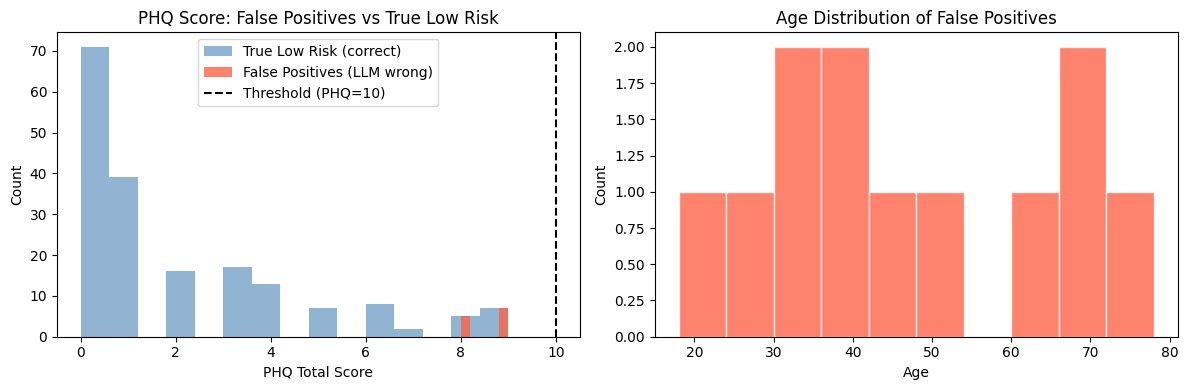

In [10]:
# PHQ score distribution of failures vs correct predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PHQ distribution: false positives vs true low risk
axes[0].hist(true_low['PHQ_total'], bins=15, alpha=0.6,
             color='steelblue', label='True Low Risk (correct)')
axes[0].hist(fp_cases['PHQ_total'], bins=5, alpha=0.8,
             color='tomato', label='False Positives (LLM wrong)')
axes[0].axvline(x=10, color='black', linestyle='--', label='Threshold (PHQ=10)')
axes[0].set_title('PHQ Score: False Positives vs True Low Risk')
axes[0].set_xlabel('PHQ Total Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# age distribution of false positives
axes[1].hist(fp_cases['RIDAGEYR'], bins=10, color='tomato',
             alpha=0.8, edgecolor='white')
axes[1].set_title('Age Distribution of False Positives')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(results + '/failure_analysis.png', dpi=150)
plt.show()

In [11]:
# Format sensitivity
# which patients fail across different formats?

valid_formats = {
    'F1_zero': pred_f1_zero,
    'F1_few': pred_f1_few,
    'F2_zero': pred_f2_zero,
}

# for each format find false positive indices
format_fp = {}
for name, preds in valid_formats.items():
    fp_idx = [i for i in range(200)
              if preds[i] == 1 and y_sample.iloc[i] == 0]
    format_fp[name] = set(fp_idx)

print("False positive patient indices per format:")
for name, idx_set in format_fp.items():
    print(f"  {name}: {len(idx_set)} patients → {sorted(idx_set)}")

# overlap — same patients failing across formats
f1z = format_fp['F1_zero']
f1f = format_fp['F1_few']
f2z = format_fp['F2_zero']

print("\nOverlap analysis:")
print("F1_zero ∩ F1_few:", len(f1z & f1f), "patients")
print("F1_zero ∩ F2_zero:", len(f1z & f2z), "patients")
print("All 3 formats:", len(f1z & f1f & f2z), "patients")
print("Only in F1_zero:", len(f1z - f1f - f2z), "patients")

False positive patient indices per format:
  F1_zero: 12 patients → [17, 34, 35, 40, 61, 70, 94, 114, 132, 140, 153, 189]
  F1_few: 13 patients → [17, 34, 35, 40, 61, 70, 73, 114, 132, 134, 140, 153, 189]
  F2_zero: 13 patients → [17, 35, 40, 61, 67, 73, 114, 132, 140, 153, 159, 189, 190]

Overlap analysis:
F1_zero ∩ F1_few: 11 patients
F1_zero ∩ F2_zero: 9 patients
All 3 formats: 9 patients
Only in F1_zero: 1 patients


In [12]:
#Who are the consistently confused patients?
consistent_failures = f1z & f1f & f2z
print("Patients failing all 3 formats:", sorted(consistent_failures))

consistent_df = analysis_df.iloc[list(consistent_failures)][
    ['RIDAGEYR', 'RIAGENDR', 'PHQ_total', 'SLD012', 'INDFMPIR', 'y_true']
]
print("\nConsistently confused patient profiles:")
print(consistent_df.to_string())

print("\nPHQ scores of consistently confused patients:")
print(sorted(consistent_df['PHQ_total'].tolist()))

Patients failing all 3 formats: [17, 35, 40, 61, 114, 132, 140, 153, 189]

Consistently confused patient profiles:
     RIDAGEYR  RIAGENDR  PHQ_total  SLD012  INDFMPIR  y_true
35       70.0       2.0          9     6.0      1.08       0
132      71.0       1.0          9    10.0      1.66       0
40       18.0       2.0          8     6.5      0.87       0
140      78.0       2.0          9     7.5      1.35       0
17       38.0       1.0          8     5.0      2.13       0
114      61.0       1.0          9    10.0      2.15       0
189      32.0       1.0          9     6.5      4.78       0
153      38.0       2.0          9     6.0      0.33       0
61       52.0       1.0          9     3.5      0.58       0

PHQ scores of consistently confused patients:
[8, 8, 9, 9, 9, 9, 9, 9, 9]


/tmp/ipykernel_3810/946835632.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')


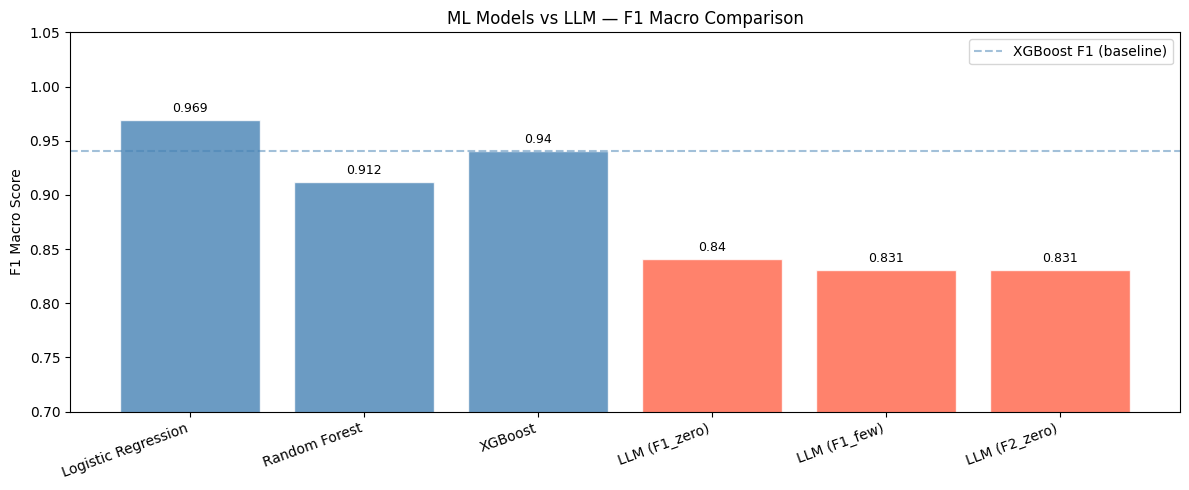

In [13]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))

# only use reliable experiments (200/200 valid)
reliable = ['F1_zero', 'F1_few', 'F2_zero']
ml_models = ['Logistic Regression', 'Random Forest', 'XGBoost']

labels = ml_models + [f'LLM ({r})' for r in reliable]
f1_scores = [0.9688, 0.9118, 0.9404] + [
    llm_metrics[llm_metrics['Experiment'] == r]['F1_macro'].values[0]
    for r in reliable
]

colors = ['steelblue', 'steelblue', 'steelblue',
          'tomato', 'tomato', 'tomato']

bars = ax.bar(labels, f1_scores, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(y=0.9404, color='steelblue', linestyle='--',
           alpha=0.5, label='XGBoost F1 (baseline)')
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('F1 Macro Score')
ax.set_title('ML Models vs LLM — F1 Macro Comparison')
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.legend()

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            str(round(score, 3)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(results + '/final_comparison.png', dpi=150)
plt.show()

In [14]:
# Final takeaway summary
summary = """
=== FINAL ANALYSIS SUMMARY ===

ML Model Performance (full test set, n=1013):
- Logistic Regression: F1=0.969, AUC=1.0
- XGBoost:             F1=0.940, AUC=0.998
- Random Forest:       F1=0.912, AUC=0.995

LLM Performance (sample n=200, reliable formats only):
- Best LLM (F1_zero):  F1=0.840, Accuracy=0.940
- LLM gap vs XGBoost:  -0.10 F1

Key Findings:
1. ML models significantly outperform LLM on tabular clinical data
2. LLM had 12 false positives, 0 false negatives (never missed high risk)
3. All false positives had PHQ scores of 8 or 9 — just below threshold
4. 9 patients failed consistently across all 3 reliable formats
5. LLM failure is not format-dependent — it's threshold-dependent
6. More complex prompts (F3, F4) caused LLM to give unparseable responses
7. LLM appears to use clinical reasoning ("PHQ=9 is concerning")
   rather than strict threshold logic ("PHQ<10 = low risk")

Main Contribution:
LLMs struggle specifically on borderline cases near hard numerical
thresholds. This is a fundamental limitation — LLMs reason contextually
while tabular classifiers learn exact decision boundaries from data.
"""

print(summary)

with open(results + '/final_summary.txt', 'w') as f:
    f.write(summary)
print("saved")


=== FINAL ANALYSIS SUMMARY ===

ML Model Performance (full test set, n=1013):
- Logistic Regression: F1=0.969, AUC=1.0
- XGBoost:             F1=0.940, AUC=0.998
- Random Forest:       F1=0.912, AUC=0.995

LLM Performance (sample n=200, reliable formats only):
- Best LLM (F1_zero):  F1=0.840, Accuracy=0.940
- LLM gap vs XGBoost:  -0.10 F1

Key Findings:
1. ML models significantly outperform LLM on tabular clinical data
2. LLM had 12 false positives, 0 false negatives (never missed high risk)
3. All false positives had PHQ scores of 8 or 9 — just below threshold
4. 9 patients failed consistently across all 3 reliable formats
5. LLM failure is not format-dependent — it's threshold-dependent
6. More complex prompts (F3, F4) caused LLM to give unparseable responses
7. LLM appears to use clinical reasoning ("PHQ=9 is concerning") 
   rather than strict threshold logic ("PHQ<10 = low risk")

Main Contribution:
LLMs struggle specifically on borderline cases near hard numerical 
thresholds. T